In [2]:
import pandas as pd

In [3]:
df=pd.read_excel(r'C:\Users\Philippe.ISOPE\Desktop\Theo Data Files\Boutons_variables\GluSnFR_avg_variables_allCa_filtered_3sigma.xlsx', sheet_name=1)

In [4]:
df.head()

,ID,AMP1,AMP2,AMP3,AMP4,AMP5,AMP6,AMP7,AMP8,AMP9,...,PPR5/1,PPR6/1,PPR7/1,PPR8/1,PPR9/1,PPR10/1,%Fail1,%Fail2,%Fail3,Target
0,20190801_linescan1_20Hz_10pulses_2.5mMCa_bouton1,0.246642,0.787000,0.770000,0.750256,0.955000,0.703913,0.818390,0.788996,0.746769,...,3.872012,2.853990,3.318133,3.198953,3.027747,3.580037,70.000000,30.0,20.000000,UN
1,20190801_linescan1_20Hz_10pulses_2.5mMCa_bouton2,0.445825,1.014894,1.598803,1.447474,1.410574,1.181167,1.228452,1.201504,1.253637,...,3.163963,2.649395,2.755458,2.695012,2.811947,3.171505,55.555556,0.0,11.111111,UN
2,20190801_linescan1_20Hz_10pulses_2.5mMCa_bouton3,0.627436,1.654345,1.401491,2.061142,1.604291,1.855009,1.689470,1.837686,1.843293,...,2.556900,2.956491,2.692657,2.928883,2.937819,3.246475,40.000000,0.0,0.000000,UN
3,20190801_linescan1_20Hz_10pulses_2.5mMCa_bouton5,0.543082,0.774586,0.846045,0.688399,1.209642,0.580878,0.748106,1.025860,1.029706,...,2.227367,1.069597,1.377519,1.888960,1.896043,1.822329,40.000000,50.0,20.000000,UN
4,20190801_linescan1_20Hz_10pulses_2.5mMCa_bouton6,0.580000,1.057000,1.132733,0.718191,0.839275,0.893894,0.796719,0.900895,1.030734,...,1.447025,1.541197,1.373654,1.553267,1.777128,1.658243,40.000000,20.0,0.000000,UN


In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [6]:
def apply_pca(df, n_components=None):
    """
    Perform Principal Component Analysis (PCA) on a Pandas DataFrame.

    Args:
    - df: Pandas DataFrame containing the data.
    - n_components: Number of components to keep. If not specified, all components will be kept.

    Returns:
    - transformed_df: Pandas DataFrame containing the transformed data with the principal components.
    - pca: The fitted PCA object.

    """
    # Standardize the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df)
  
    # Apply PCA
    pca = PCA(n_components=n_components)
    transformed_data = pca.fit_transform(scaled_data)

    # Create a new DataFrame with the transformed data
    transformed_df = pd.DataFrame(transformed_data, columns=[f"PC{i+1}" for i in range(transformed_data.shape[1])])

    return transformed_df, pca

In [7]:
new_df=df.drop(['ID', 'AMP2','AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3','Target'], axis=1) 
#df.drop(df.iloc[:,3:10])
new_df.head()
labels = new_df.columns
print (labels)

Index(['AMP1', 'PPR2/1', 'PPR3/1', 'PPR4/1', 'PPR5/1', 'PPR6/1', 'PPR7/1',
       'PPR8/1', 'PPR9/1', 'PPR10/1', '%Fail1', '%Fail2'],
      dtype='object')


In [8]:
new_df

,AMP1,PPR2/1,PPR3/1,PPR4/1,PPR5/1,PPR6/1,PPR7/1,PPR8/1,PPR9/1,PPR10/1,%Fail1,%Fail2
0,0.246642,3.190862,3.121936,3.041885,3.872012,2.853990,3.318133,3.198953,3.027747,3.580037,70.000000,30.0
1,0.445825,2.276439,3.586167,3.246730,3.163963,2.649395,2.755458,2.695012,2.811947,3.171505,55.555556,0.0
2,0.627436,2.636676,2.233680,3.285025,2.556900,2.956491,2.692657,2.928883,2.937819,3.246475,40.000000,0.0
3,0.543082,1.426278,1.557859,1.267579,2.227367,1.069597,1.377519,1.888960,1.896043,1.822329,40.000000,50.0
4,0.580000,1.822414,1.952988,1.238260,1.447025,1.541197,1.373654,1.553267,1.777128,1.658243,40.000000,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...
140,0.424167,1.783707,2.083987,1.943073,1.910329,1.858608,1.899657,1.654553,1.891774,2.266839,30.000000,0.0
141,0.406005,1.832762,1.835540,1.956329,2.019905,1.696891,2.099301,1.731058,1.927536,1.903097,10.000000,0.0
142,0.495801,1.930210,2.081480,1.794048,1.913789,1.776977,1.569178,1.703521,1.401860,1.731051,20.000000,0.0
143,0.797845,2.051777,1.637680,1.568489,1.713416,1.685791,1.098086,1.201086,1.372447,1.542837,0.000000,0.0


In [9]:
transformed_df, pca = apply_pca(new_df, n_components=2)

In [10]:
print(transformed_df.head())

        PC1       PC2
0  7.735377  0.015646
1  5.935068 -1.455403
2  5.273551 -2.073258
3 -0.193337  1.244607
4 -0.373118 -0.010377


In [11]:
print(" explained variance: ", pca.explained_variance_ratio_)
print (" pca components:  ", pca.components_)


 explained variance:  [0.62679773 0.15980787]
 pca components:   [[-0.20517379  0.26635991  0.31270906  0.32918384  0.3328318   0.32784272
   0.32770103  0.32543574  0.32717989  0.32775697  0.18554162  0.01886555]
 [-0.46766726 -0.14451157 -0.11661311 -0.10379176 -0.02779524 -0.03106302
  -0.06673873 -0.0571544  -0.06326981 -0.06118466  0.5477032   0.64718529]]


In [12]:
from sklearn.cluster import KMeans

In [13]:
# Assuming you have the transformed DataFrame 'transformed_df'
# Specify the number of clusters you want to create
n_clusters = 5

# Apply K-Means clustering
kmeans = KMeans(n_clusters=n_clusters, n_init= 'auto')
kmeans.fit(transformed_df)

# Get the cluster labels
cluster_labels = kmeans.labels_

# Add the cluster labels to the transformed DataFrame
transformed_df['Cluster'] = cluster_labels

# Print the transformed DataFrame with the cluster labels
print(transformed_df.head())

        PC1       PC2  Cluster
0  7.735377  0.015646        3
1  5.935068 -1.455403        3
2  5.273551 -2.073258        3
3 -0.193337  1.244607        1
4 -0.373118 -0.010377        1


C:\Users\Philippe.ISOPE\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


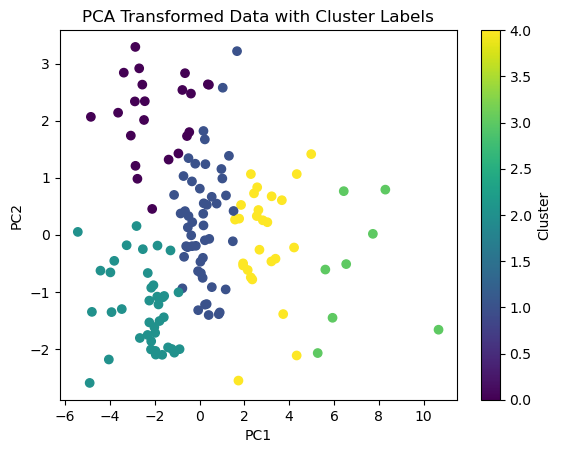

In [14]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Assuming you have the transformed DataFrame 'transformed_df' with the 'Cluster' column
# Plot the transformed data with cluster labels in different colors
plt.scatter(transformed_df['PC1'], transformed_df['PC2'], c=transformed_df['Cluster'], cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Transformed Data with Cluster Labels')
plt.colorbar(label='Cluster')
plt.show
plt.savefig('PCA.pdf')

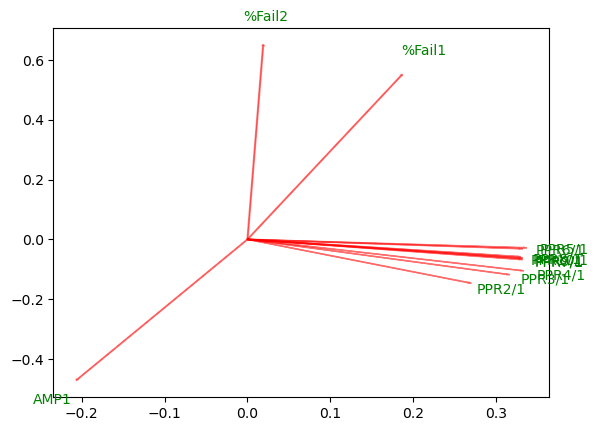

In [15]:
import numpy as np
coeff = np.transpose(pca.components_[0:2, :])
n = coeff.shape[0]
for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1],color = 'r',alpha = 0.5)
        plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, labels[i], color = 'g', ha = 'center', va = 'center')
plt.savefig('PCA components.pdf')

In [16]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples, silhouette_score


# Assuming you have the transformed DataFrame 'transformed_df' with the 'Cluster' column
# Calculate the silhouette score
silhouette_avg = silhouette_score(transformed_df, transformed_df['Cluster'])
print('Silhouette Score:', silhouette_avg)

Silhouette Score: 0.4897885435456913


Text(0.5, 0.98, 'Silhouette analysis for KMeans clustering on sample data with n_clusters = 5')

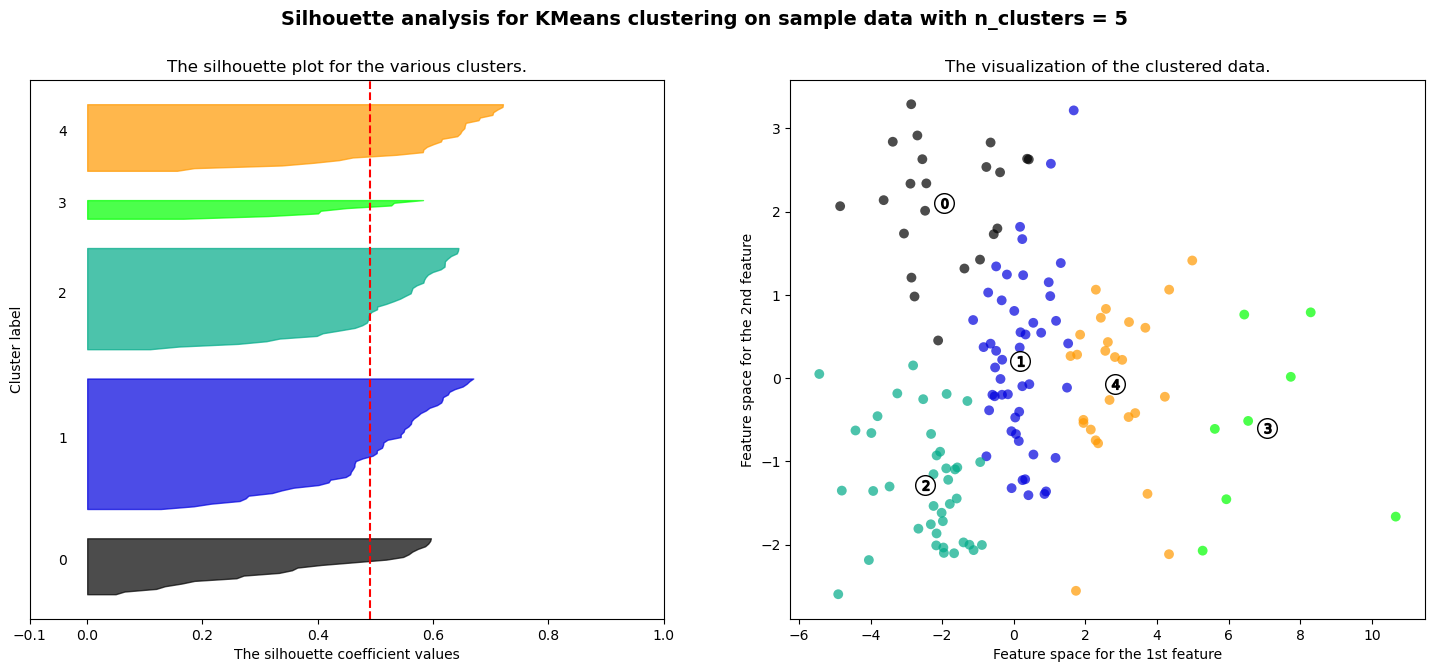

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(18, 7)

sample_silhouette_values = silhouette_samples(transformed_df, transformed_df['Cluster'])

y_lower = 10
for i in range(n_clusters):
    # Aggregate the silhouette scores for samples belonging to
    # cluster i, and sort them
    ith_cluster_silhouette_values = sample_silhouette_values[transformed_df['Cluster'] == i]

    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / n_clusters)
    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )

    # Label the silhouette plots with their cluster numbers at the middle
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples

ax1.set_title("The silhouette plot for the various clusters.")
ax1.set_xlabel("The silhouette coefficient values")
ax1.set_ylabel("Cluster label")

# The vertical line for average silhouette score of all the values
ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

ax1.set_yticks([])  # Clear the yaxis labels / ticks
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

# 2nd Plot showing the actual clusters formed
colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
ax2.scatter(
    transformed_df['PC1'], transformed_df['PC2'], marker=".", s=200, lw=0, alpha=0.7, c=colors, edgecolor="k"
)
# Labeling the clusters
centers = kmeans.cluster_centers_
# Draw white circles at cluster centers
ax2.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="o",
    c="white",
    alpha=1,
    s=200,
    edgecolor="k",
)
for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

ax2.set_title("The visualization of the clustered data.")
ax2.set_xlabel("Feature space for the 1st feature")
ax2.set_ylabel("Feature space for the 2nd feature")

plt.suptitle(
    "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
    % n_clusters,
    fontsize=14,
    fontweight="bold",
)
      